# Summer-Lull ☀️
### "Sell in May and go away" — sound seasonal, terrible advice

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sell in May is good advice?: Not supported](https://img.shields.io/badge/Sell_in_May_is_good_advice%3F-Not_supported-8b949e?style=flat-square)

It's the oldest saw on Wall Street: dump your stocks in May, buy back at Halloween. And the seasonal it's built on is *real* — winter has beaten summer for nearly a century. Yet following the rule leaves you with **less money** than doing nothing, because summer still pays. A true pattern, a losing trade.

> 📓 **Plain-language layer.** The t-stat and the persistence are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (summer_lull/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from summer_lull import data, strategy as st
ret = data.fetch_index()                       # cache-first
sp = st.seasonal_split(ret)
sim, bh = st.sell_in_may(ret), st.buy_hold(ret)


## The answer first 🎯

| The saying | The data (1928–2026) |
|---|---|
| "Stocks do better in winter" | True: **+5.3%/yr** winter vs **+2.7%/yr** summer. |
| "So sell in May" | But summer is **positive** — you'd skip free money. |
| "It beats buy-and-hold" | Same Sharpe (0.43 vs 0.42), **a third less wealth**. |

## 1 · The claim

The Halloween indicator (Bouman & Jacobsen 2002): hold equities Nov–Apr, step into cash May–Oct, because the summer months are weak. Quoted every spring.

## 2 · So what?

If a calendar rule this simple beat the market, everyone would run it. The honest question isn't whether winter > summer (it does) but whether *avoiding summer* helps — and that depends entirely on whether summer returns are negative or merely smaller.

## 3 · How would we even know?

Split a century of S&P returns into winter and summer, test the gap, then run the rule (cash all summer) against buy-and-hold — and check the one number that decides it: **is the summer return positive?**

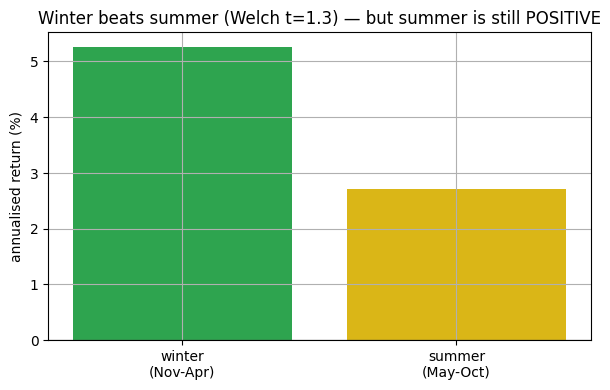

In [2]:
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['winter\n(Nov-Apr)','summer\n(May-Oct)'],[sp['winter_ann']*100,sp['summer_ann']*100],color=['#2ea44f','#dab617'])
ax.set_ylabel('annualised return (%)'); ax.axhline(0,color='k',lw=.8)
ax.set_title(f"Winter beats summer (Welch t={sp['welch_t']:.1f}) — but summer is still POSITIVE"); plt.show()

## 4 · The teardown

Summer is the weaker season, not a bad one. So sitting it out just keeps you out of the market half the year — for no Sharpe gain.

,cagr,sharpe,max_drawdown
Sell-in-May (cash in summer),4.5%,0.43,-71%
Buy & hold,6.3%,0.42,-86%


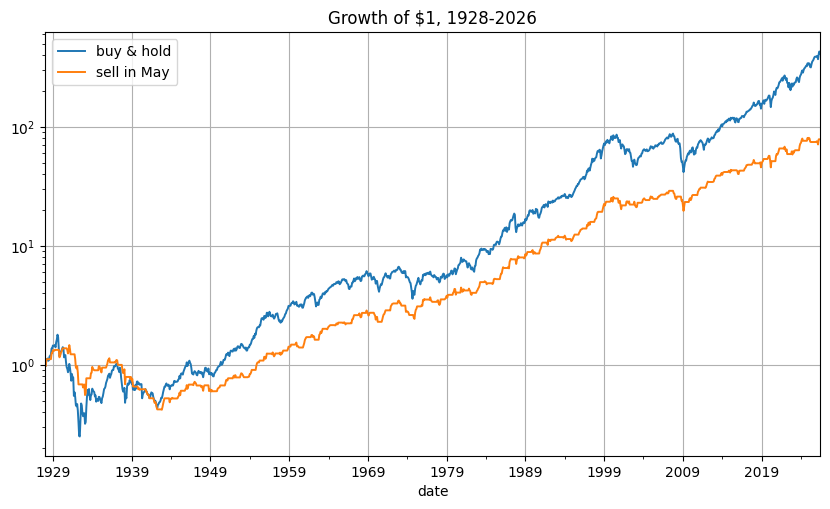

In [3]:
rows={'Sell-in-May (cash in summer)':st.summary(sim),'Buy & hold':st.summary(bh)}
t=pd.DataFrame(rows).T[['cagr','sharpe','max_drawdown']]
display(t.style.format({'cagr':'{:.1%}','sharpe':'{:.2f}','max_drawdown':'{:.0%}'}))
eqS=(1+sim).cumprod(); eqB=(1+bh).cumprod()
ax=eqB.plot(label='buy & hold',lw=1.4); eqS.plot(ax=ax,label='sell in May',lw=1.4)
ax.set_yscale('log'); ax.set_title('Growth of $1, 1928-2026'); ax.legend(); plt.show()

**Read it plainly.** Two lines, same slope of risk-adjusted return — but the sell-in-May line ends lower because it skipped a positive season. Same illusion as [Hangover](../../41-hangover/) and [Last-Call](../../42-last-call/).

## 5 · The verdict

**Signal: Weak** — real, persistent, but soft (t 1.3). **Tradability: Mirage** — same Sharpe, less wealth. **Sell in May good advice?: Not supported** — summer pays.

## 6 · Could you actually trade it?

You could, trivially — and you'd underperform a do-nothing investor. If you genuinely want less risk, hold a bit less equity all year; don't make a calendar bet that forgoes a positive season.

## 7 · Going further 🚪

The quants notebook shows the seasonal persists for a century (Jacobsen-Zhang 2018) — and why that *still* doesn't make the trade work. Contrast with [Study 48 Groundhog](../../48-groundhog/), the seasonal that genuinely is tradable.